# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.2

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

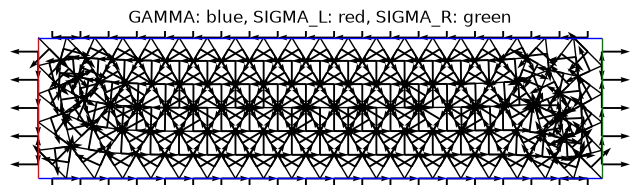

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [6]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.LEFT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [7]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [8]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [ ]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, NtD_modes=NtD_modes, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [10]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 13
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

3146

and an assembler:

In [11]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [ ]:
from trefftz.problem import Problem
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [13]:
A = P.assemble_LHS()

Interior: 100%|██████████| 338/338 [00:12<00:00, 27.06edge/s]


assembling local operators
region: Gamma


100%|██████████| 40/40 [00:00<00:00, 192.91edge/s]


region: Sigma_L


100%|██████████| 5/5 [00:00<00:00, 209.75edge/s]


region: Sigma_R


100%|██████████| 5/5 [00:00<00:00, 210.57edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 5/5 [00:10<00:00,  2.06s/edge]


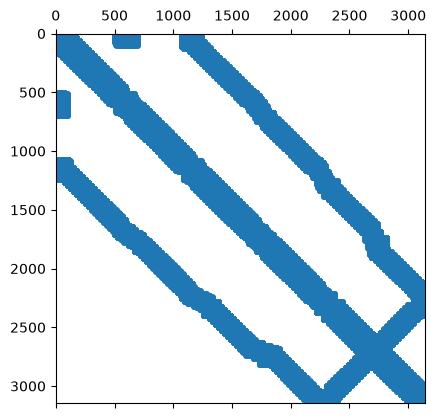

In [14]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [15]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [16]:
b = P.assemble_RHS()

In [17]:
P.solve()

In [18]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 7.81608576e+01+46.37042165j, -1.33044420e+01 -2.72649546j,
         5.61155058e+01+82.111654j  , ..., -3.79360863e+01+21.82203685j,
        -1.90842391e+01-43.94741003j, -8.90743664e+00+14.2820638j ],
       [ 5.41848180e+00+14.51559601j, -1.21113542e+01 +6.36691471j,
         5.88678510e+00 +7.28756585j, ...,  1.82813098e+00 +5.68955713j,
         4.72365279e-01 +9.00399518j, -1.36182057e+01 +0.27950787j],
       [ 2.81124405e+01 +2.90208421j,  5.14667397e+00 -3.20740864j,
         2.22760152e-01+15.17662442j, ...,  2.78614587e+00 +1.27506796j,
        -1.52138534e+01-10.00741658j, -2.71486340e+01 -9.38506075j],
       ...,
       [-1.05120311e+00 -1.42794022j,  4.76729210e-01 +0.41750948j,
        -1.26043056e+00 +2.04068521j, ..., -3.91596662e-01 -0.98125098j,
        -2.38214559e+00 +0.15047808j,  1.30044018e+00 -2.23134575j],
       [-4.57448478e+00 -4.731018j  ,  7.68406899e+00 +3.49783047j,
         7.84382686e-01 +8.52326236j, ...,  6.66371422e+00 +2.59657625j,
       

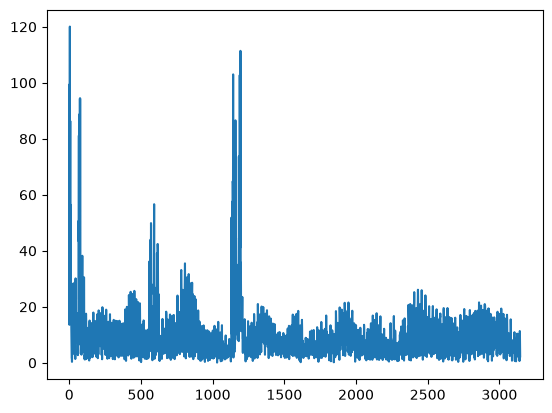

In [19]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [20]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

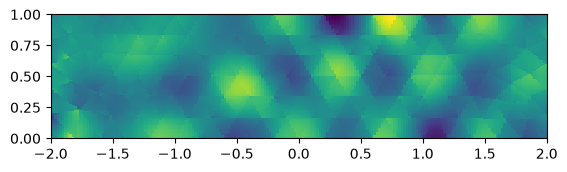

In [21]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

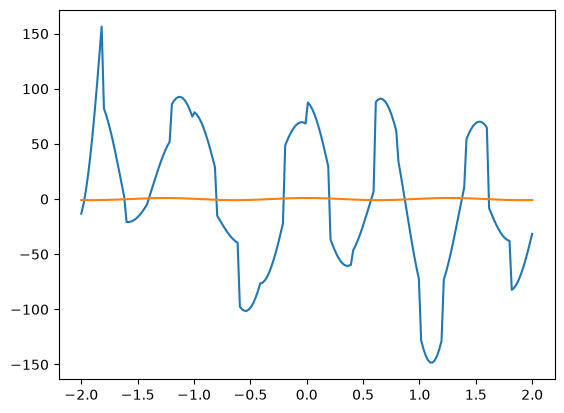

In [22]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)